## Music League Stats

All of the data is scraped into a pandas dataframe with each row being an entry, with submitter name, song id, votes from all other players, and other stats scraped from the spotify API.

In [2]:
from pathlib import Path
from datetime import datetime, timedelta
from functools import reduce
from operator import add

import numpy as np
import matplotlib.pyplot as plt
from  matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.dates as mdates


from scraper import translator, create_dataframe
from spotify_data import get_spotify_data, get_playlist, playlists

Dump the files from the downloaded webpage into `/music_league/` in the root of this directory. It has to be the full html and media download, just html doesn't contain the voting information unfortunately.

In [3]:
path = Path("../music_league_2/")

df, names = create_dataframe(path=path, translator=translator) # translator is a dictionary that converts music league names to actual names
df = get_spotify_data(music_league_df=df)

In [4]:
round_names = (
    "Boxing Entrance",
    "Best Sample",
    "Best Live Version",
    "Obscurity",
    "Best solo breakout",
    "Best summer song",
    "To the Polls",
    "Song with a drink in the title",
    "One hit wonder",
    "Riskaware anthem"
)

df["round_name"] = df["round"].astype(int).map(lambda i: round_names[i-1])

In [5]:
winning_order = df.groupby(df["submitter"])[names].sum().sum(axis=1)
winning_order = winning_order.sort_values(ascending=False).index

df["round_score"] = df[names].sum(axis=1)

# Round winners

for round_name, (round, scores) in zip(round_names, df.groupby("round")):
    winning_score = scores["round_score"].max()
    a = f"Round {round:<4} | {round_name}"
    print(a + "\n" + '-'*len(a))
    for _, row in scores[scores["round_score"] == winning_score][["submitter", "track_name", "round_score"]].iterrows():
        print(f"{row['submitter']:10} | {row['track_name']:40} | {int(row['round_score'])}")
    print()


Round 1    | Boxing Entrance
----------------------------
Martha     | X Gon' Give It To Ya                     | 23

Round 2    | Best Sample
------------------------
Jamie      | Stan                                     | 19

Round 3    | Best Live Version
------------------------------
Jenny S    | The Man Who Sold The World - Live        | 23

Round 4    | Obscurity
----------------------
Jamie      | Sweet Reprieve                           | 16
Helen      | Pictures                                 | 16

Round 5    | Best solo breakout
-------------------------------
Helen      | Edge of Seventeen                        | 20

Round 6    | Best summer song
-----------------------------
Martha     | Mas Que Nada                             | 21

Round 7    | To the Polls
-------------------------
Martha     | Zombie                                   | 19

Round 8    | Song with a drink in the title
-------------------------------------------
Helen      | Black Coffee                

## Biggest scores per round

In [6]:
df.sort_values("round_score", ascending=False).iloc[:10][["round_name", "submitter", "track_name", "round_score"]]

,round_name,submitter,track_name,round_score
21,Boxing Entrance,Martha,X Gon' Give It To Ya,23.0
123,Best Live Version,Jenny S,The Man Who Sold The World - Live,23.0
82,Best summer song,Martha,Mas Que Nada,21.0
143,Best solo breakout,Helen,Edge of Seventeen,20.0
0,Riskaware anthem,Mark,We Care a Lot,19.0
164,Best Sample,Jamie,Stan,19.0
102,To the Polls,Martha,Zombie,19.0
124,Best Live Version,Martha,Burning Down the House - Live,18.0
41,Song with a drink in the title,Helen,Black Coffee,18.0
125,Best Live Version,Bethany,Lapdance (Live),18.0


In [7]:
df.sort_values("round_score", ascending=True).iloc[:10][["round_name", "submitter", "track_name", "round_score"]]

,round_name,submitter,track_name,round_score
142,Best Live Version,Olek,Final - Live Version - Rappel,-13.0
122,To the Polls,Sam,Do They Know It's Christmas? - 1984 Version,-11.0
20,Riskaware anthem,Fred,Funny Little Man,-11.0
163,Best solo breakout,Tim C,Paranoid (2012 - Remaster),-10.0
61,Song with a drink in the title,Mark,Tubthumping,-8.0
204,Obscurity,Olek,Phobia - Live,-7.0
81,One hit wonder,Olek,Love Is All I Got,-6.0
121,To the Polls,Olek,Woman,-6.0
162,Best solo breakout,Sam,Wonderful Christmastime - Full Length Version ...,-6.0
19,Riskaware anthem,Sacha,We Will Rise,-5.0


## Voting Matrix

The voting matrix shows the net votes of all competitors across all of the rounds. Rows are the points received, columns the points given. The rows and columns are sorted into the final order of the league

In [8]:
# arr has shape (num_rounds, num_competitors, num_competitors)
# Any missing values are filled with 0.0

arr = np.concatenate([
        group.reindex(winning_order, fill_value=0.0).to_numpy()[None, :, :]
        for _, group in df.set_index(df["submitter"]).groupby("round")[winning_order]], axis=0)
voting_matrix = np.sum(arr, axis=0)

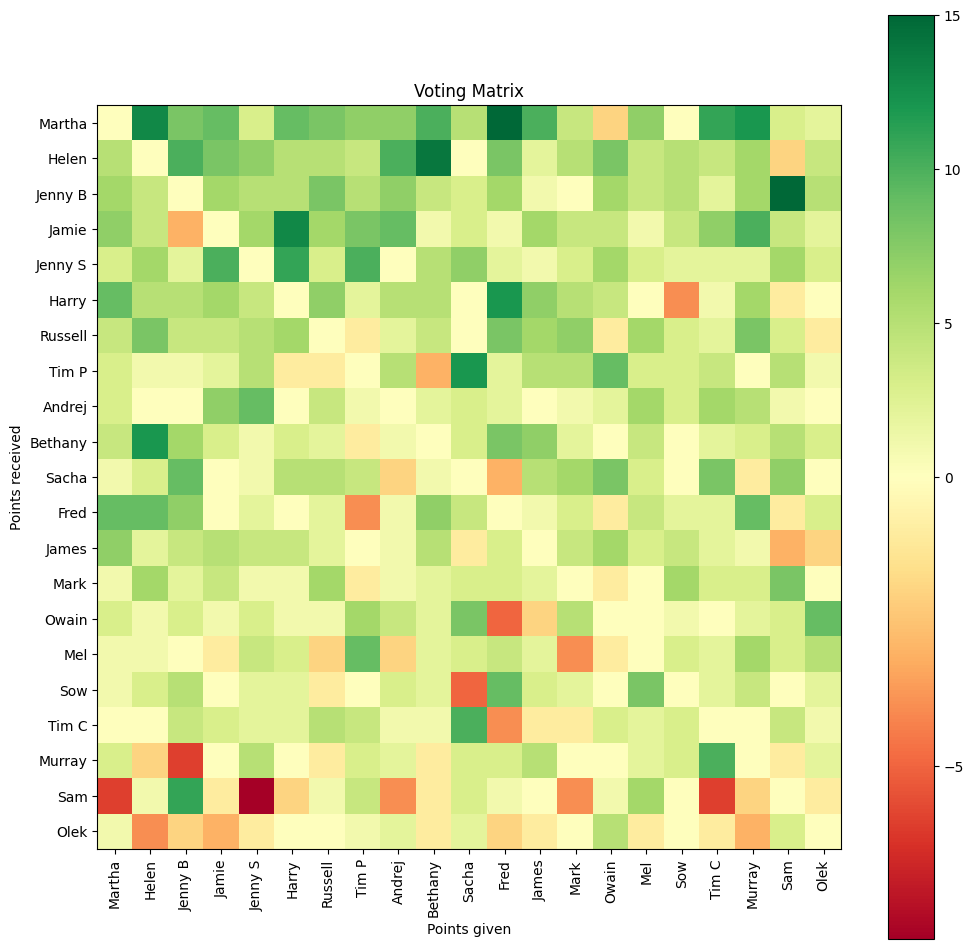

In [10]:
fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(voting_matrix),
                        vcenter=0,
                        vmax=np.max(voting_matrix))

plt.imshow(voting_matrix, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.xlabel("Points given")
plt.ylabel("Points received")
plt.title("Voting Matrix")


cbar = plt.colorbar()

plt.show()

List the top ten biggest stans and haters

In [11]:
most_correlated = np.unravel_index(np.argsort(-voting_matrix.reshape(-1))[:10], voting_matrix.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} for {winning_order[row]}: {int(voting_matrix[row, col])}")


Fred for Martha: 15
Sam for Jenny B: 15
Bethany for Helen: 14
Helen for Martha: 13
Harry for Jamie: 13
Murray for Martha: 12
Sacha for Tim P: 12
Fred for Harry: 12
Helen for Bethany: 12
Harry for Jenny S: 11


In [13]:
biggest_haters = np.unravel_index(np.argsort(voting_matrix.reshape(-1))[:10], voting_matrix.shape)
for row, col in zip(*biggest_haters):
    print(f"{winning_order[col]} for {winning_order[row]}: {int(voting_matrix[row, col])}")


Jenny S for Sam: -8
Jenny B for Murray: -6
Martha for Sam: -6
Tim C for Sam: -6
Sacha for Sow: -5
Fred for Owain: -5
Mark for Mel: -4
Tim P for Fred: -4
Sow for Harry: -4
Fred for Tim C: -4


## Voting Correlation

See who votes similarly... and who doesn't

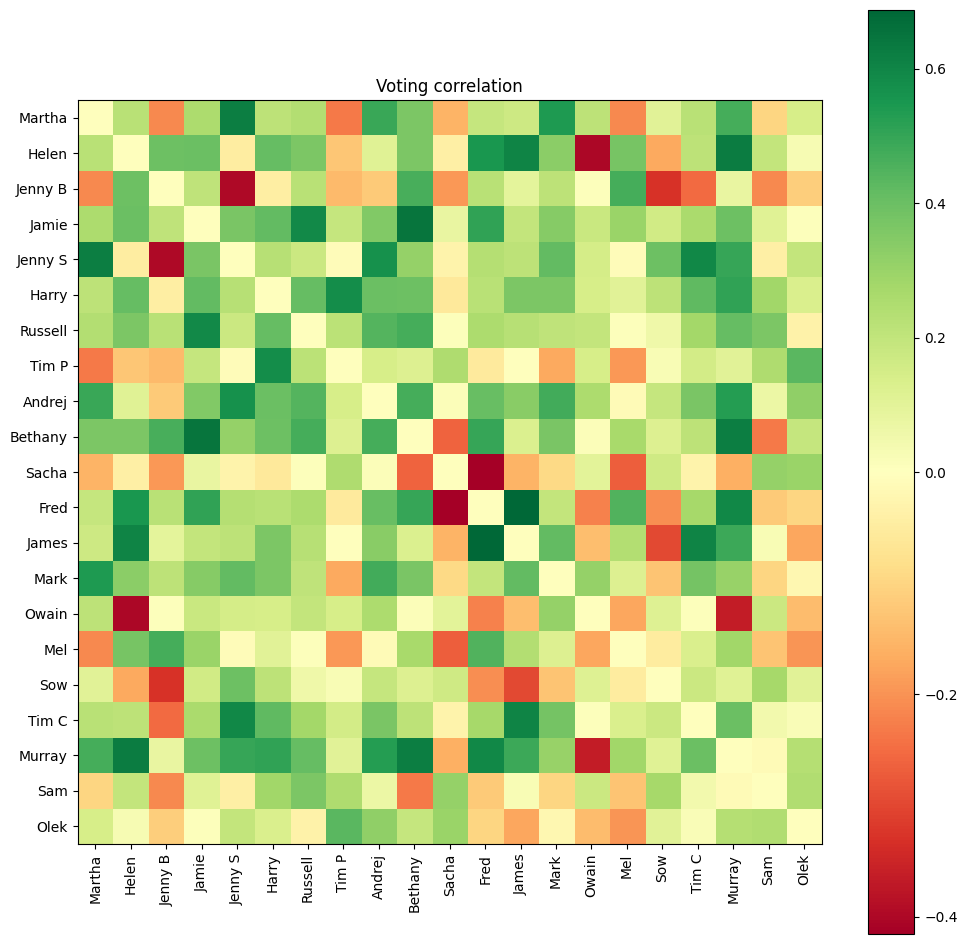

In [15]:
# Sort arr into an array that's lists of each competitors votes per round

voting_correlation = np.corrcoef(np.vstack(voting_matrix).T)
np.fill_diagonal(voting_correlation, 0.0)

fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(voting_correlation),
                        vcenter=0,
                        vmax=np.max(voting_correlation))

plt.imshow(voting_correlation, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.title("Voting correlation")


cbar = plt.colorbar()

plt.show()

In [16]:
most_correlated = np.unravel_index(np.argsort(-voting_correlation.reshape(-1))[:20:2], voting_matrix.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_correlation[row, col]:.2f}")

James and Fred: 0.69
Bethany and Jamie: 0.65
Helen and Murray: 0.63
Jenny S and Martha: 0.62
Murray and Bethany: 0.62
James and Helen: 0.60
Tim C and James: 0.60
Tim C and Jenny S: 0.59
Murray and Fred: 0.59
Jamie and Russell: 0.59


In [17]:
most_correlated = np.unravel_index(np.argsort(voting_correlation.reshape(-1))[:20:2], voting_matrix.shape)
for row, col in zip(*most_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_correlation[row, col]:.2f}")

Sacha and Fred: -0.42
Helen and Owain: -0.40
Jenny S and Jenny B: -0.40
Owain and Murray: -0.36
Jenny B and Sow: -0.33
Sow and James: -0.30
Mel and Sacha: -0.27
Bethany and Sacha: -0.26
Jenny B and Tim C: -0.25
Martha and Tim P: -0.23


## Genre Correlation

See who submits similar genres

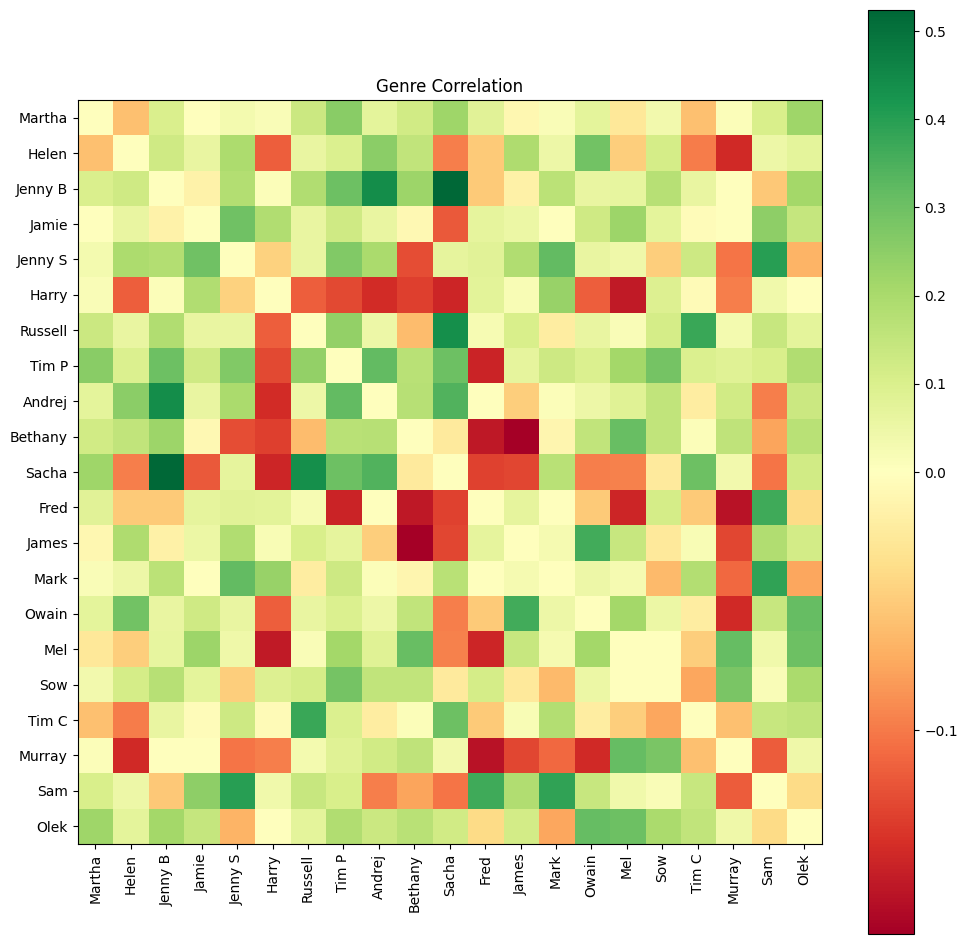

In [ ]:
unique_genres = set()

for submitter in winning_order:
    rest = set(reduce(add, df[df.submitter != submitter]["genres"].values))
    unique_genres |= set(reduce(add, df[df.submitter == submitter]["genres"])).difference(rest)

all_genres = list({genre for genres in df.genres for genre in genres}.difference(unique_genres))
from functools import reduce
from operator import add
x = df.groupby("submitter")["genres"].apply(lambda x: reduce(add, x)).reindex(winning_order).map(set)

genre_matrix = np.zeros((len(winning_order), len(all_genres)))

for i, genres in enumerate(x.values):
    for j, genre in enumerate(all_genres):
        if genre in genres:
            genre_matrix[i][j] = 1.0

voting_matrix = np.corrcoef(genre_matrix)
np.fill_diagonal(voting_matrix, 0.0)

fig, ax = plt.subplots(figsize=(12,12))

cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256)
norm = TwoSlopeNorm(vmin=np.min(voting_matrix),
                        vcenter=0,
                        vmax=np.max(voting_matrix))

plt.imshow(voting_matrix, cmap='RdYlGn', norm=norm, interpolation='nearest')
plt.xticks(np.arange(len(winning_order)), winning_order, rotation='vertical')
plt.yticks(np.arange(len(winning_order)), winning_order)
plt.title("Genre Correlation")


cbar = plt.colorbar()

plt.show()

In [ ]:
print(f"Most Genre Correlated\n{'-'*21}")
genre_correlated = np.unravel_index(np.argsort(-voting_matrix.reshape(-1))[:20:2], voting_matrix.shape)
for row, col in zip(*genre_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_matrix[row, col]:.2f}")

Most Genre Correlated
---------------------
Jenny B and Sacha: 0.52
Andrej and Jenny B: 0.44
Russell and Sacha: 0.44
Sam and Jenny S: 0.40
Mark and Sam: 0.39
Russell and Tim C: 0.37
Fred and Sam: 0.36
James and Owain: 0.36
Andrej and Sacha: 0.34
Jenny S and Mark: 0.32


In [ ]:
print(f"Least Genre Correlated\n{'-'*21}")
genre_correlated = np.unravel_index(np.argsort(voting_matrix.reshape(-1))[:20:2], voting_matrix.shape)
for row, col in zip(*genre_correlated):
    print(f"{winning_order[col]} and {winning_order[row]}: {voting_matrix[row, col]:.2f}")

Least Genre Correlated
---------------------
James and Bethany: -0.18
Murray and Fred: -0.16
Bethany and Fred: -0.16
Harry and Mel: -0.16
Tim P and Fred: -0.15
Fred and Mel: -0.15
Sacha and Harry: -0.15
Murray and Helen: -0.15
Owain and Murray: -0.15
Harry and Andrej: -0.15


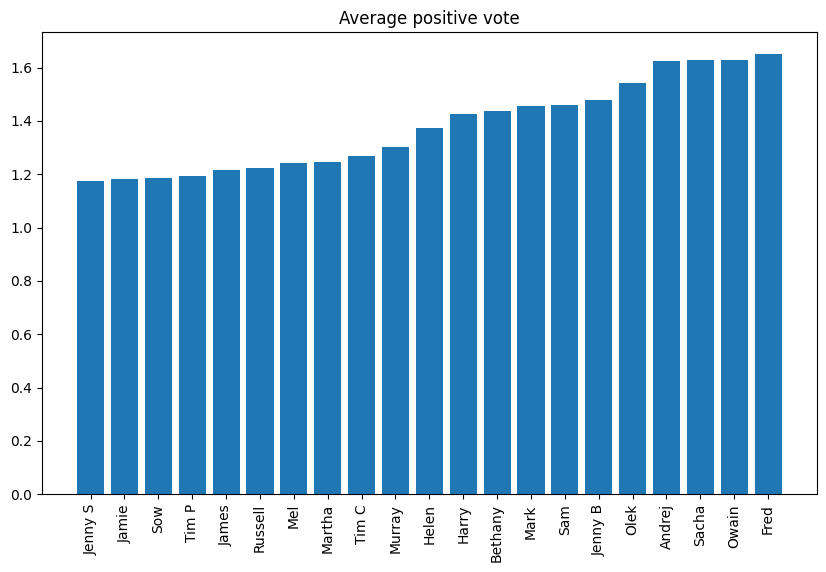

In [ ]:
x = arr.reshape(-1, len(winning_order))
x[x <= 0.0] = np.nan
a = np.nanmean(x, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Average positive vote")

ax.bar(np.arange(len(winning_order)), a[np.argsort(a)])
ax.set_xticks(np.arange(len(winning_order)), labels=[winning_order[i] for i in np.argsort(a)], rotation="vertical")

plt.show()

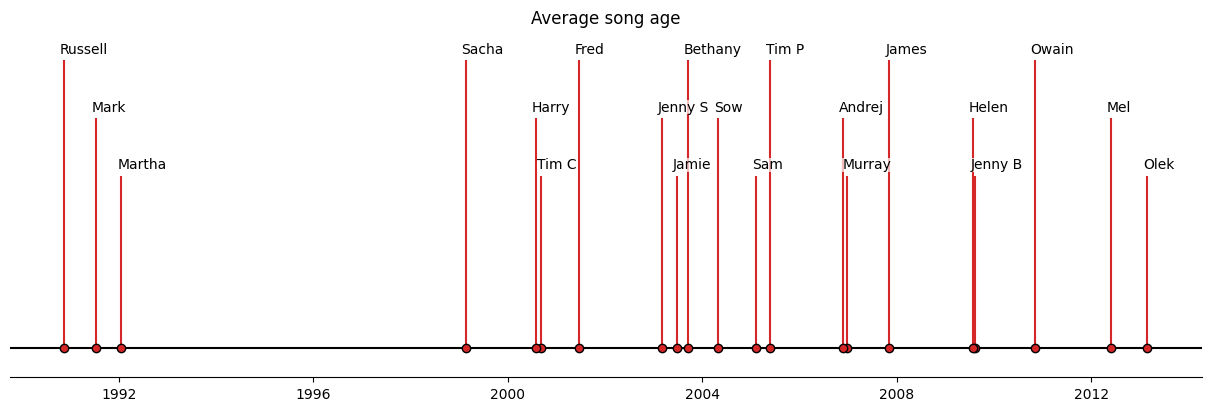

In [31]:
# Average song age

df["song_age_seconds"] = (datetime.now() - df["date"]).dt.total_seconds()
ages = df.groupby("submitter")["song_age_seconds"].mean().sort_values().map(lambda x: datetime.now() - timedelta(seconds=x))

fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
ax.set(title="Average song age")

levels = [(i % 3) / 3 + 1 for i in range(len(ages))]

# The vertical stems.
ax.vlines(ages, 0, levels,
          color=[("tab:red", 1)
                 for _ in ages])
# The baseline.
ax.axhline(0, c="black")
# The markers on the baseline
ax.plot(ages, np.zeros_like(ages), "ko", mfc="tab:red")

# Annotate the lines.
for date, level, name in zip(ages, levels, ages.index):
    ax.annotate(name, xy=(date, level),
                xytext=(-3, np.sign(level)*3), textcoords="offset points",
                verticalalignment="bottom" if level > 0 else "top",
                bbox=dict(boxstyle='square', pad=0, lw=0, fc=(1, 1, 1, 0.7)))

ax.yaxis.set(major_locator=mdates.YearLocator(),
             major_formatter=mdates.DateFormatter("%Y"))

# Remove the y-axis and some spines.
ax.yaxis.set_visible(False)
ax.spines[["left", "top", "right"]].set_visible(False)

ax.margins(y=0.1)
plt.show()

In [32]:
# Does song age correlate with overall ranking?

np.corrcoef(np.c_[ages.reindex(winning_order).argsort(), np.arange(len(ages))].T)

array([[1.        , 0.28961039],
       [0.28961039, 1.        ]])

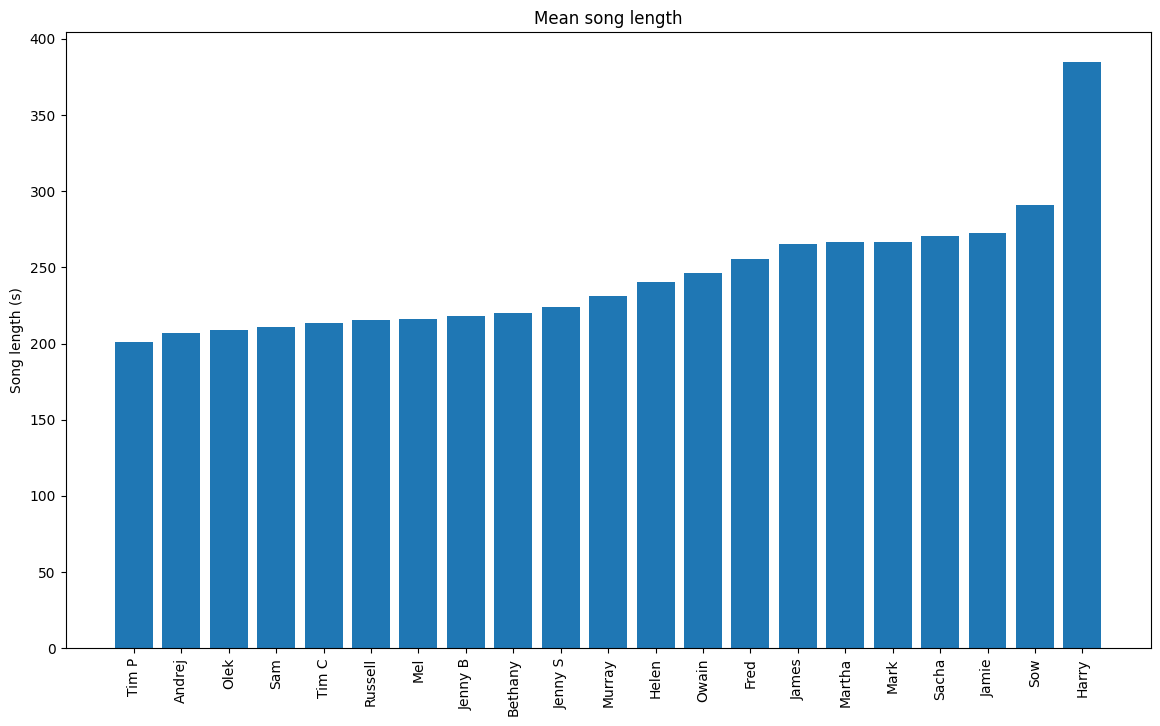

In [33]:
lengths = df.groupby("submitter")["duration"].mean().sort_values()

fig, ax = plt.subplots(figsize=(14, 8))

ax.bar(np.arange(len(lengths)), lengths)
ax.set_xticks(np.arange(len(winning_order)), lengths.index, rotation='vertical')
ax.set_title("Mean song length")
ax.set_ylabel("Song length (s)")
plt.show()

In [34]:
df.sort_values("duration", ascending=False)[["submitter", "track_name", "duration"]].iloc[:10]

,submitter,track_name,duration
137,Harry,"The Curtain - Live From Dordrecht, Het Energie...",909.106
109,Harry,Zombie,745.653
112,Mel,Hurricane,512.732
132,Sow,Recurring/We Could Forever - Live,479.573
200,Mark,"Given Up - Original 12"" Mix",464.000
15,Martha,Computer Love - 2009 Remaster,439.440
83,Harry,Hot Hot Hot,404.426
164,Jamie,Stan,404.106
77,James,Music Sounds Better With You,403.293
191,Sow,Sweetness Is My Weakness,390.413


In [35]:
df[df["round"]!=8].sort_values("duration")[["submitter", "track_name", "duration"]].iloc[:10]

,submitter,track_name,duration
33,Tim P,Theme from Strictly Come Dancing,42.000
202,Sam,Fire Alarm,85.395
110,Tim C,Tory Is A 4 Letter Word Pt II,100.586
3,Andrej,Cut Every Corner,109.275
6,Mel,Got The Autism,115.384
38,Bethany,Nervous Breakdown,129.173
104,Jenny B,We Live Here,131.876
99,Sam,The Spark,146.384
195,Mel,Why They Do That?,148.480
107,Jamie,For What It's Worth,153.693


In [36]:
# Energy

df.groupby("submitter")["energy"].mean().sort_values(ascending=False)

submitter
Sacha      0.862400
Helen      0.842400
Tim P      0.829100
Mark       0.812571
Owain      0.805900
Bethany    0.797100
Jenny B    0.781700
Jenny S    0.772800
Olek       0.770700
James      0.762500
Mel        0.751200
Tim C      0.731200
Sow        0.715250
Russell    0.714400
Fred       0.710900
Murray     0.704230
Martha     0.701700
Sam        0.643100
Harry      0.641800
Andrej     0.640200
Jamie      0.636200
Name: energy, dtype: float64

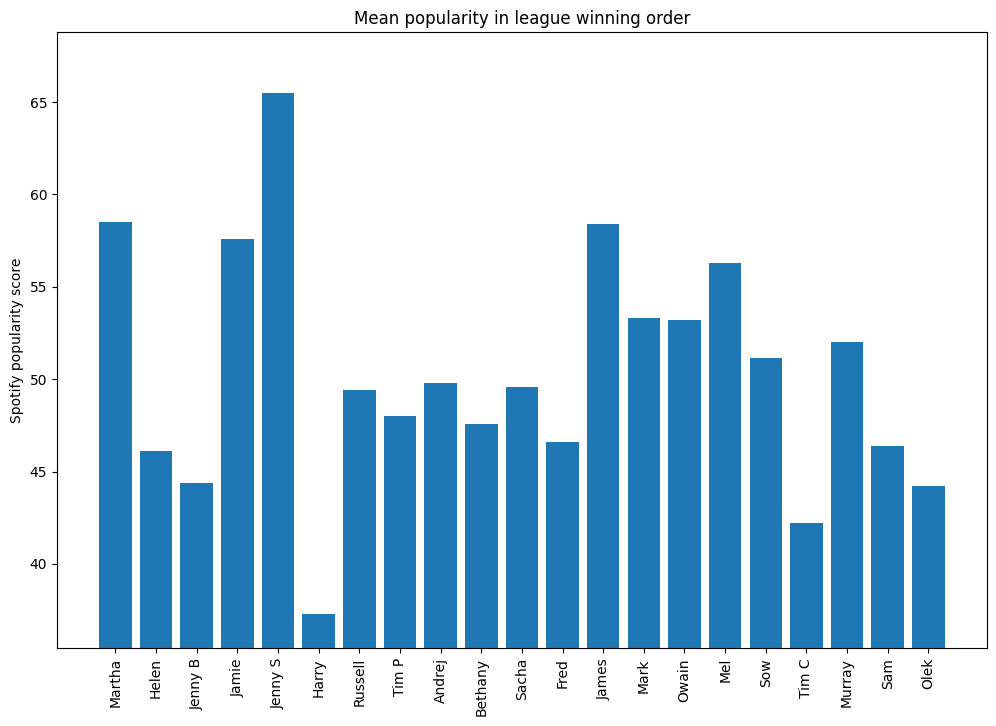

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))

pop = df.groupby("submitter")["popularity"].mean().sort_values(ascending=False)

ax.bar(np.arange(len(pop)), pop.reindex(winning_order))
ax.set_xticks(range(len(pop)), winning_order, rotation="vertical")
ax.set_ylim(min(pop)*0.95, max(pop)*1.05)
ax.set_ylabel("Spotify popularity score")

plt.title("Mean popularity in league winning order")

plt.show()

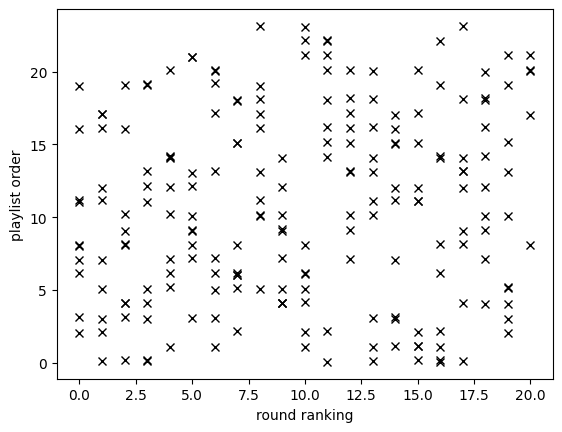

In [38]:
i, a = list(df.groupby("round"))[0]
playlists = [get_playlist(playlist) for playlist in playlists]
vals = []

for i, a in df.groupby("round"):
    vals.append(a.sort_values("round_score", ascending=False)["song_id"].map(lambda x: playlists[i-1].index(x)))

rankings = np.array([i for df in vals for i in range(len(df))])
playlist_order = np.array([i for df in vals for i in df.values])

# Add noise
playlist_order = playlist_order + np.random.random(*playlist_order.shape) * 0.2

plt.xlabel("round ranking")
plt.ylabel("playlist order")

plt.plot(rankings, playlist_order, "kx")
plt.show()


In [39]:
np.corrcoef(rankings, playlist_order)

array([[1.        , 0.11964283],
       [0.11964283, 1.        ]])

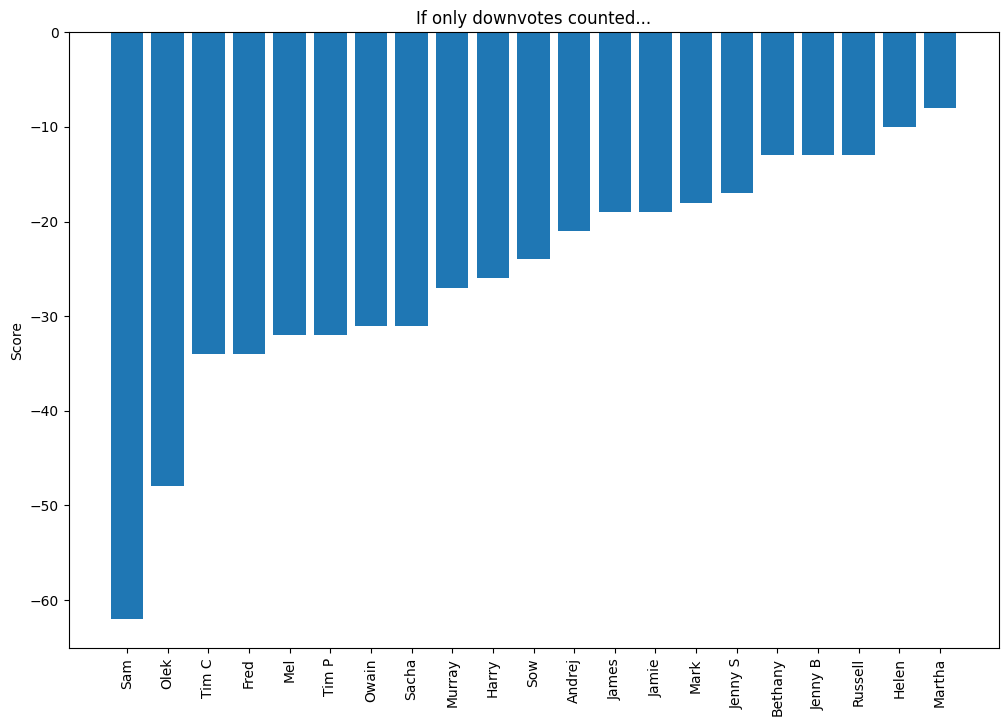

In [40]:
negative_votes = np.where(arr < 0, arr, 0)

negative_scores = np.sum(negative_votes, axis=(0, 2))

order = np.argsort(negative_scores)

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(np.arange(len(winning_order)), np.sort(negative_scores))
ax.set_xticks(range(len(winning_order)), winning_order[order], rotation="vertical")
ax.set_ylabel("Score")
ax.set_title("If only downvotes counted...")

plt.show()


## Controversy Function

The controversy score $C$ is calculated using the following formula:


$C = \sqrt{\frac{1}{N_{\neq 0}} \sum_{i=1}^{N_{\neq 0}} (v_i - \mu)^2} \times \left( \sum_{i=1}^{n} v_i \text{ where } v_i > 0 \ - \ \alpha \sum_{i=1}^{n} v_i \text{ where } v_i < 0 \right)$


Where:
- $v_i$ are the individual votes.
- $\mu$ is the mean of the non-zero votes.
- $N_{\neq 0}$ is the number of non-zero votes.
- $\alpha$ is the ratio of positive to negative votes ($\frac{10}{3}$ in this league)
- The first part of the equation represents the standard deviation of the non-zero votes.
- The second part represents a modified range that accounts for positive and scaled negative votes.


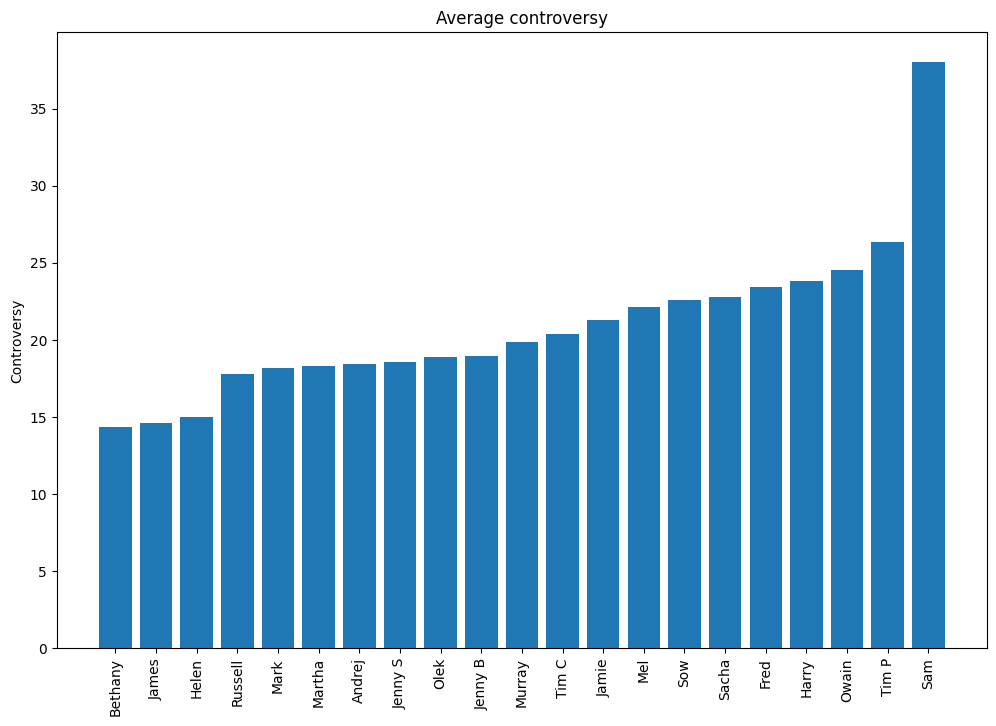

In [41]:
def controversy(vals):
    std = np.std([i for i in vals if i])
    range = sum(i for i in vals if i > 0.0) - (sum(i for i in vals if i < 0.0) * 10/3)
    return std * range
df["controversy"] = df[names].apply(controversy, axis=1)
df.sort_values("controversy", ascending=False)[["submitter", "track_name", "round", "controversy"]].iloc[:10]

fig, ax = plt.subplots(figsize=(12, 8))

vals = df.groupby("submitter")["controversy"].mean().sort_values()

ax.bar(np.arange(len(vals)), vals)
ax.set_xticks(range(len(vals)), vals.index, rotation="vertical")
ax.set_ylabel("Controversy")
ax.set_title("Average controversy")

plt.show()

In [42]:
df.sort_values("controversy", ascending=False)[["controversy", "submitter", "round_name", "track_name"]].iloc[:10]

,controversy,submitter,round_name,track_name
80,87.689741,Sam,One hit wonder,Imagine - Remastered 2010
92,74.884876,Sacha,Best summer song,My Own Summer (Shove It)
137,69.565516,Harry,Best Live Version,"The Curtain - Live From Dordrecht, Het Energie..."
135,62.590379,Tim P,Best Live Version,"Free Fallin' - Live at the Nokia Theatre, Los ..."
20,57.940946,Fred,Riskaware anthem,Funny Little Man
142,57.693939,Olek,Best Live Version,Final - Live Version - Rappel
2,56.935134,Jenny B,Riskaware anthem,The Creativity Song
202,55.217439,Sam,Obscurity,Fire Alarm
140,55.152386,Owain,Best Live Version,Bohemian Rhapsody - Live At Wembley Stadium / ...
33,52.056593,Tim P,Boxing Entrance,Theme from Strictly Come Dancing
